In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [2]:
customers=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv'))
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [4]:
customers.shape

(99441, 5)

In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [6]:
customers.duplicated().sum()

np.int64(0)

In [7]:
customers.duplicated(subset=['customer_id']).sum()

np.int64(0)

In [8]:
sellers=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv'))
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [9]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [10]:
sellers.shape

(3095, 4)

In [11]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [12]:
sellers.duplicated().sum()

np.int64(0)

In [13]:
order_review=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv'))
order_review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [14]:
order_review.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [15]:
order_review.shape

(99224, 7)

In [16]:
order_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [17]:
order_review.duplicated().sum()

np.int64(0)

In [18]:
order_review.duplicated(subset=['review_comment_message']).sum()

np.int64(63064)

In [19]:
order_items=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv'))
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [20]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [21]:
order_items.shape

(112650, 7)

In [22]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [23]:
order_items.duplicated().sum()

np.int64(0)

In [24]:
products=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv'))
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [25]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [26]:
products.shape

(32951, 9)

In [27]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [28]:
products.duplicated().sum()

np.int64(0)

In [29]:
g_location=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv'))
g_location.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [30]:
g_location.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [31]:
g_location.shape

(1000163, 5)

In [32]:
g_location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [33]:
g_location.duplicated().sum()

np.int64(261831)

In [34]:
p_category=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv'))
p_category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [35]:
p_category.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [36]:
p_category.shape

(71, 2)

In [37]:
p_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [38]:
p_category.duplicated().sum()

np.int64(0)

In [39]:
orders=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv'))
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [40]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [41]:
orders.shape

(99441, 8)

In [42]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [43]:
orders.duplicated().sum()

np.int64(0)

In [44]:
o_payment=pd.read_csv(os.path.join('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv'))
o_payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [45]:
o_payment.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [46]:
o_payment.shape

(103886, 5)

In [47]:
o_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [48]:
o_payment.duplicated().sum()

np.int64(0)

In [49]:
customers['customer_city_clean']=customers['customer_city'].apply(
    lambda x: ''.join(char for char in str(x) if ord(char)<128)
)
customers[['customer_city','customer_city_clean']].head()

,customer_city,customer_city_clean
0,franca,franca
1,sao bernardo do campo,sao bernardo do campo
2,sao paulo,sao paulo
3,mogi das cruzes,mogi das cruzes
4,campinas,campinas


In [50]:
#clean customer_city
customers['customer_city_clean']=(customers['customer_city_clean'].str.lower().str.strip())
customers['customer_city_clean'].head()

0                   franca
1    sao bernardo do campo
2                sao paulo
3          mogi das cruzes
4                 campinas
Name: customer_city_clean, dtype: object

In [51]:
#find rows special characters
def has_non_ascii(text):
    return any(ord(char) >127 for char in str(text))
special_rows=customers[customers['customer_city'].apply(has_non_ascii)]
special_rows.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_clean


In [52]:
#filter cities starting with vowels
vowels=[ord('A'),ord('E'),ord('I'),ord('O'),ord('U'),ord('a'),ord('e'),ord('i'),ord('o'),ord('u')]
vowel_cities=customers[customers['customer_city'].apply(lambda x: ord(str(x)[0]) in vowels)]
vowel_cities.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_clean
21,690172ab319622688d3b4df42f676898,a96d5cfa0d3181817e2b946f921ea021,74914,aparecida de goiania,GO,aparecida de goiania
46,f34a6e874087ec1f0e3dab9fdf659c5d,233896de79986082f1f479f1f85281cb,38300,ituiutaba,MG,ituiutaba
72,6d27a9361e591da38c87a5e70253f3f2,76b029c87118a29f2e3de420f5ec2fa2,38408,uberlandia,MG,uberlandia
77,1b2cb35b19b40b61f953d32ea157b337,468d559ef2dcd2bea6d8db78959fb90f,83709,araucaria,PR,araucaria
81,8392e3d4cfeec63f2a8bfea68bf1f91f,fd2d5fdb84e65fa6b54b98b0e2df5645,59655,areia branca,RN,areia branca


In [53]:
#convert first letter to ascii number
customers['city_first_letter_ascii']=customers['customer_city'].apply(
    lambda x :ord(str(x)[0])
)
customers[['customer_city','city_first_letter_ascii']].head()

,customer_city,city_first_letter_ascii
0,franca,102
1,sao bernardo do campo,115
2,sao paulo,115
3,mogi das cruzes,109
4,campinas,99


In [54]:
#convert ascii back to character
customers['ascii_back_to_char']=customers['city_first_letter_ascii'].apply(chr)
customers[['city_first_letter_ascii','ascii_back_to_char']].head()

,city_first_letter_ascii,ascii_back_to_char
0,102,f
1,115,s
2,115,s
3,109,m
4,99,c


In [55]:
#sort cities based on ascii
customers_sorted=customers.sort_values(by='city_first_letter_ascii')
customers_sorted.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_clean,city_first_letter_ascii,ascii_back_to_char
99351,f83083fcbc51d12f8279b5713c2d4b4d,0465f164e35aba70f70e911b252513a9,77807,araguaina,TO,araguaina,97,a
99406,d9110683c7a282144e9fc97660026a28,5cbfdb85ec130898108b32c50d619c39,74980,aparecida de goiania,GO,aparecida de goiania,97,a
73180,d2da057d4083d5150c6275d1d17b7070,3dadc7103d20bae9a1d9e0ade0314b5e,28970,araruama,RJ,araruama,97,a
73244,891966aa607cc04bf5575d6b22ef9e57,d1da2c3c54238beabf857d2d7fe4e8ab,29230,anchieta,ES,anchieta,97,a
73239,2f7001da9e597c4b707313a341a20614,38c576114024f3c3e45f83e7b5ee0c56,59965,alexandria,RN,alexandria,97,a


In [56]:
non_ascii_count=customers['customer_city'].apply(
    lambda x: any(ord(char) >127 for char in str(x))
).sum()
print("Number of cities with special characters:",non_ascii_count)

Number of cities with special characters: 0


In [57]:
#convert datetime

orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at']=pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date']=pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date']=pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']=pd.to_datetime(orders['order_estimated_delivery_date'])
orders.info()


order_review['review_creation_date']=pd.to_datetime(order_review['review_creation_date'])
order_review['review_answer_timestamp']=pd.to_datetime(order_review['review_answer_timestamp'])
order_review.info()

order_items['shipping_limit_date']=pd.to_datetime(order_items['shipping_limit_date'])
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype    

In [58]:
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_year']=orders['order_purchase_timestamp'].dt.year
orders['order_month']=orders['order_purchase_timestamp'].dt.month
orders['order_day']=orders['order_purchase_timestamp'].dt.day
orders['order_dayofweek']=orders['order_purchase_timestamp'].dt.day_name()


orders[['order_year','order_month','order_day','order_dayofweek']].head()

,order_year,order_month,order_day,order_dayofweek
0,2017,10,2,Monday
1,2018,7,24,Tuesday
2,2018,8,8,Wednesday
3,2017,11,18,Saturday
4,2018,2,13,Tuesday


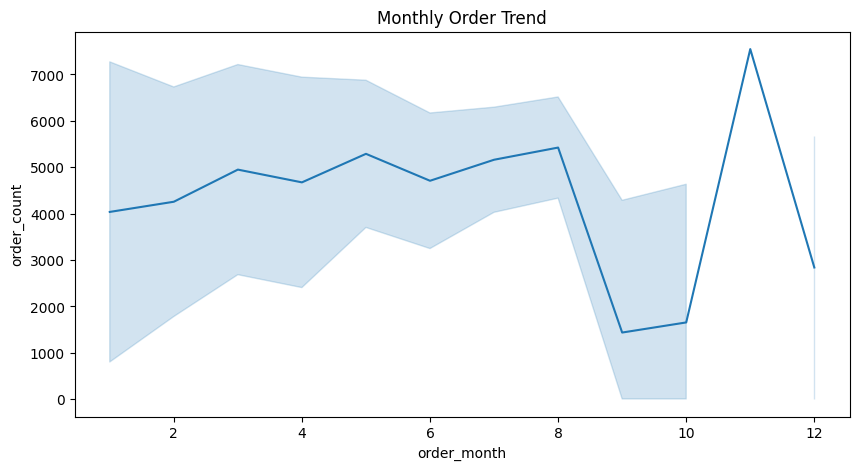

In [59]:
monthly_orders=orders.groupby(['order_year','order_month']).size().reset_index(name='order_count')

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_orders, x='order_month', y='order_count')
plt.title("Monthly Order Trend")
plt.show()

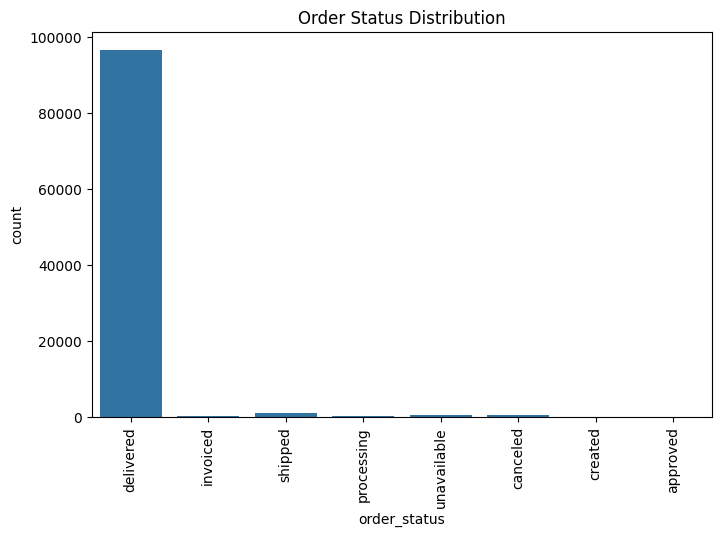

In [60]:
plt.figure(figsize=(8,5))
sns.countplot(data=orders, x='order_status')
plt.xticks(rotation=90)
plt.title("Order Status Distribution")
plt.show()

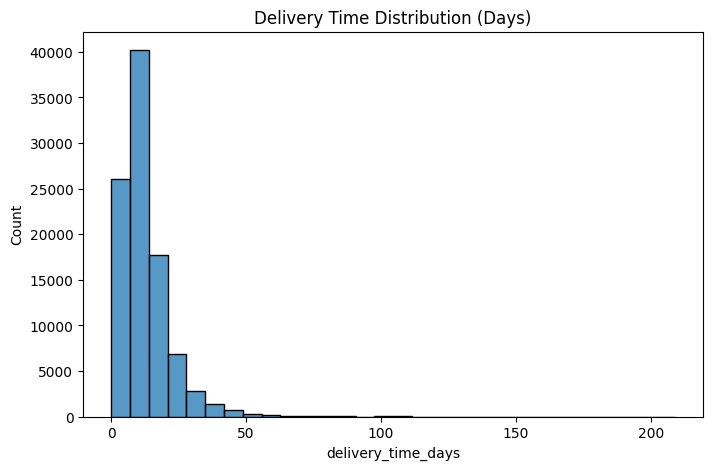

In [61]:
#calculate delivery time

orders['delivery_time_days']=(
    orders['order_delivered_customer_date']-orders['order_purchase_timestamp']
).dt.days


plt.figure(figsize=(8,5))
sns.histplot(orders['delivery_time_days'], bins=30)
plt.title("Delivery Time Distribution (Days)")
plt.show()

In [62]:
orders['is_late']=orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
late_percentage= orders['is_late'].mean()*100
print("Late Delivery %:",round(late_percentage,2))

Late Delivery %: 7.87


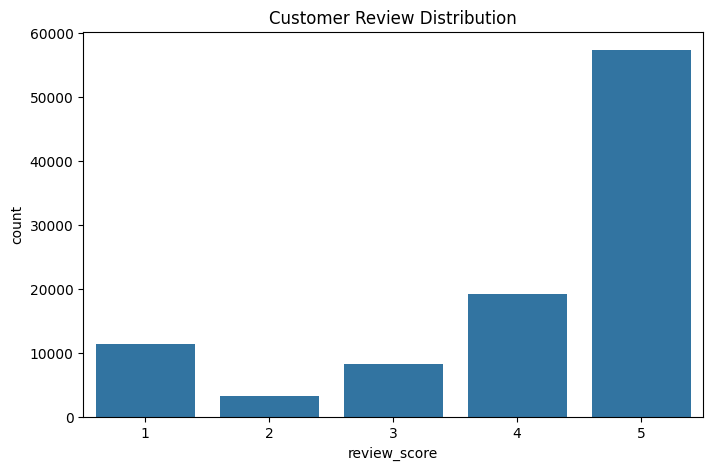

In [63]:
plt.figure(figsize=(8,5))
sns.countplot(data=order_review, x='review_score')
plt.title("Customer Review Distribution")
plt.show()

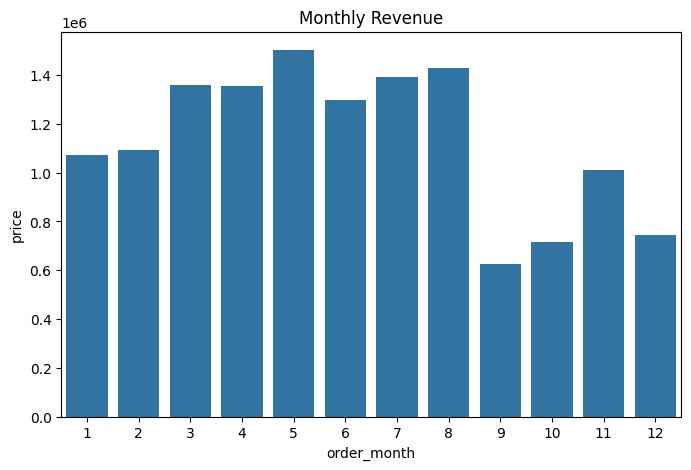

In [64]:
order_revenue=order_items.groupby('order_id')['price'].sum().reset_index()
orders_revenue=pd.merge(orders,order_revenue, on='order_id')
monthly_revenue=orders_revenue.groupby('order_month')['price'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=monthly_revenue, x='order_month',y='price')
plt.title("Monthly Revenue")
plt.show()

In [65]:
#merge revenue
order_revenue=order_items.groupby('order_id')['price'].sum().reset_index()
orders_rfm=pd.merge(orders,order_revenue, on='order_id')
orders_rfm=orders_rfm[orders_rfm['order_status']=='delivered']

orders_rfm.info()
orders_rfm.shape

orders_rfm['order_status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 98665
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   order_status                   96478 non-null  object        
 3   order_purchase_timestamp       96478 non-null  datetime64[ns]
 4   order_approved_at              96464 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96476 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96478 non-null  datetime64[ns]
 8   order_year                     96478 non-null  int32         
 9   order_month                    96478 non-null  int32         
 10  order_day                      96478 non-null  int32         
 11  order_dayofweek     

order_status
delivered    96478
Name: count, dtype: int64

In [66]:
#create RFM Table

snapshot_date=orders_rfm['order_purchase_timestamp'].max()
rfm=orders_rfm.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x:(snapshot_date - x.max()).days ,
    'order_id': 'count',
    'price': 'sum'
}).reset_index()

rfm.columns=['customer_id','Recency','Frequency','Monetary']
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,287,1,89.80
1,000161a058600d5901f007fab4c27140,409,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,547,1,179.99
3,0002414f95344307404f0ace7a26f1d5,378,1,149.90
4,000379cdec625522490c315e70c7a9fb,149,1,93.00


In [67]:
#RFM score

rfm['R_score']=pd.qcut(rfm['Recency'],4, labels=[4,3,2,1])
rfm['F_score']=pd.qcut(rfm['Frequency'].rank(method='first'),4 ,labels=[1,2,3,4])
rfm['M_score']=pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score']=rfm[['R_score','F_score','M_score']].astype(str).sum(axis=1)


#rfm['RFM_score']=rfm[['R_score','F_score',"M_score"]].astype(int).sum(axis=1)
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,287,1,89.80,2,1,3,213
1,000161a058600d5901f007fab4c27140,409,1,54.90,1,1,2,112
2,0001fd6190edaaf884bcaf3d49edf079,547,1,179.99,1,1,4,114
3,0002414f95344307404f0ace7a26f1d5,378,1,149.90,1,1,3,113
4,000379cdec625522490c315e70c7a9fb,149,1,93.00,3,1,3,313


In [68]:
rfm['R_score']=pd.qcut(rfm['Recency'],4, labels=[4,3,2,1])
rfm['F_score']=pd.qcut(rfm['Frequency'].rank(method='first'),4 ,labels=[1,2,3,4])
rfm['M_score']=pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score']=rfm[['R_score','F_score','M_score']].astype(str).sum(axis=1)


rfm['RFM_score']=rfm[['R_score','F_score',"M_score"]].astype(int).sum(axis=1)
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,287,1,89.80,2,1,3,6
1,000161a058600d5901f007fab4c27140,409,1,54.90,1,1,2,4
2,0001fd6190edaaf884bcaf3d49edf079,547,1,179.99,1,1,4,6
3,0002414f95344307404f0ace7a26f1d5,378,1,149.90,1,1,3,5
4,000379cdec625522490c315e70c7a9fb,149,1,93.00,3,1,3,7


In [69]:
#segment customers

def segment(row):
    if row['RFM_score']=='444':
        return 'Champions'
    elif row['F_score']==4:
        return 'Loyal Customers'
    elif row['R_score']==4:
        return 'Recent Customers'
    else:
        return 'Others'


rfm['Segment']=rfm.apply(segment, axis=1)
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,00012a2ce6f8dcda20d059ce98491703,287,1,89.80,2,1,3,6,Others
1,000161a058600d5901f007fab4c27140,409,1,54.90,1,1,2,4,Others
2,0001fd6190edaaf884bcaf3d49edf079,547,1,179.99,1,1,4,6,Others
3,0002414f95344307404f0ace7a26f1d5,378,1,149.90,1,1,3,5,Others
4,000379cdec625522490c315e70c7a9fb,149,1,93.00,3,1,3,7,Others


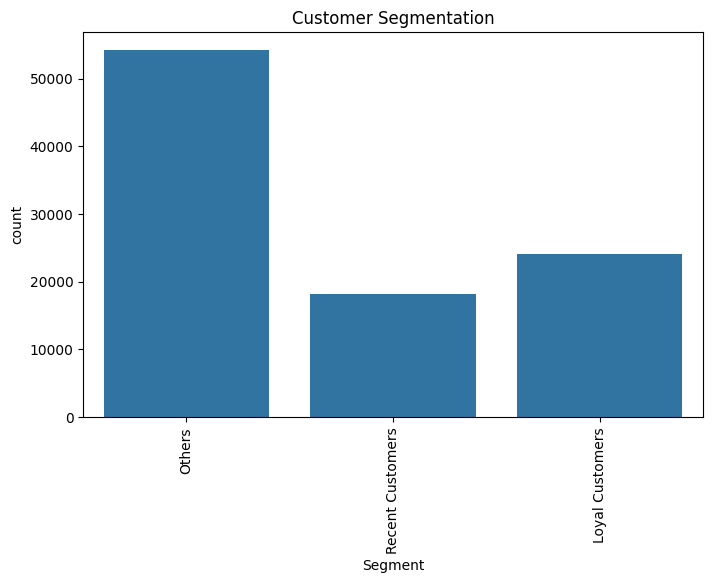

In [70]:
plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x='Segment')
plt.xticks(rotation=90)
plt.title("Customer Segmentation")
plt.show()

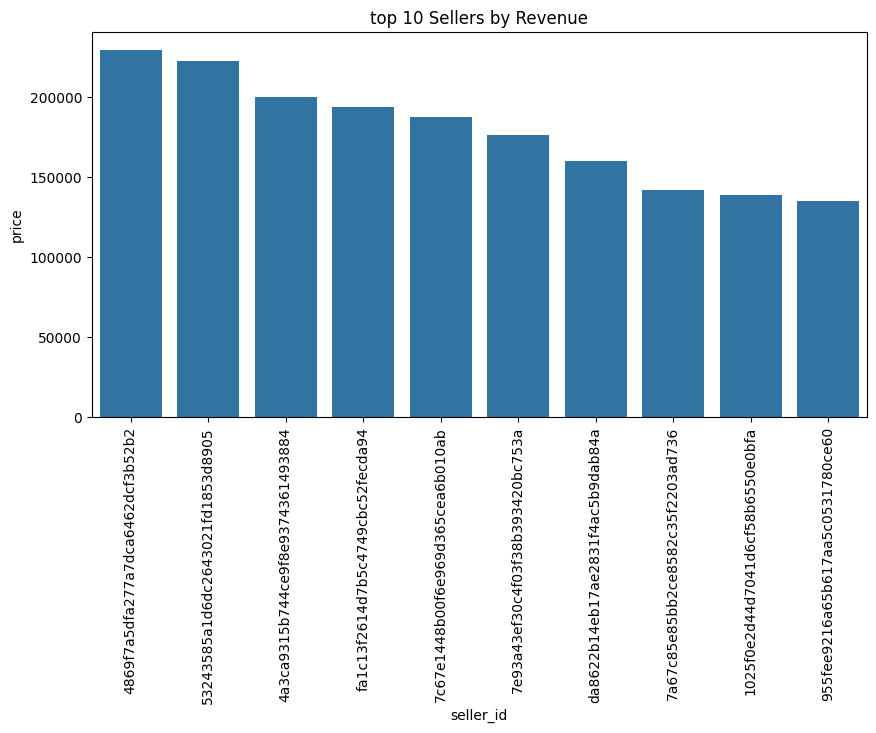

In [71]:
seller_revenue=order_items.groupby('seller_id')['price'].sum().reset_index()
top_sellers= seller_revenue.sort_values(by='price', ascending=False).head(10)


plt.figure(figsize=(10,5))
sns.barplot(data=top_sellers, x='seller_id', y='price')
plt.xticks(rotation=90)
plt.title("top 10 Sellers by Revenue")
plt.show()

In [72]:
seller_reviews=pd.merge(order_items,order_review,on='order_id')

seller_rating = seller_reviews.groupby('seller_id')['review_score'].mean().reset_index()
seller_rating.head()

,seller_id,review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542
2,001e6ad469a905060d959994f1b41e4f,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,3.982143
4,003554e2dce176b5555353e4f3555ac8,5.000000


In [73]:
#cohort analysis
orders=orders.copy()
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_month']=orders['order_purchase_timestamp'].dt.to_period('M')

cohort=(
    orders
    .groupby('customer_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)


cohort.columns=['customer_id','cohort_month']

#remove old column if exists
orders=orders.drop(columns=['cohort_month'],errors='ignore')

#merging columns
orders=orders.merge(cohort, on='customer_id',how='left')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_day,order_dayofweek,delivery_time_days,is_late,cohort_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,2,Monday,8.0,False,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,24,Tuesday,13.0,False,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,8,Wednesday,9.0,False,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,18,Saturday,13.0,False,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,13,Tuesday,2.0,False,2018-02


In [74]:
cohort_data=orders.groupby(['cohort_month','order_month'])\
            .agg(n_customers=('customer_id','nunique'))\
            .reset_index()
cohort_pivot=cohort_data.pivot(index='cohort_month',
                              columns='order_month',
                              values='n_customers')
cohort_pivot.shape

(25, 25)

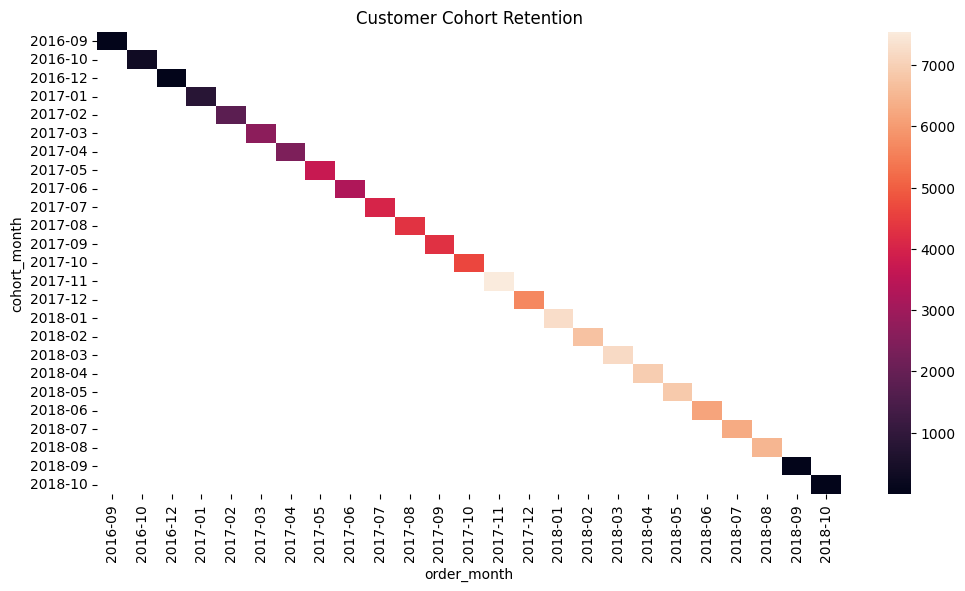

In [75]:
plt.figure(figsize=(12,6))
sns.heatmap(cohort_pivot,annot=False)
plt.title("Customer Cohort Retention")
plt.show()

In [76]:
total_revenue=order_items['price'].sum()
total_orders=orders['order_id'].nunique()
total_customers=orders['customer_id'].nunique()
avg_order_value=total_revenue/total_orders

print("Total Revenue:",round(total_revenue,2))
print("Total Orders:",total_orders)
print("Total Customers:",total_customers)
print("Average Order Value:",round(avg_order_value,2))

Total Revenue: 13591643.7
Total Orders: 99441
Total Customers: 99441
Average Order Value: 136.68


In [77]:
#missing value audit

def missing_report(df):
    missing =df.isnull().sum()
    percent = (missing/len(df))*100
    report =pd.DataFrame({
        'Missing_Count':missing,
        'Missing_Percentage':percent
    })
    return report[report['Missing_Count']>0].sort_values(by='Missing_Percentage', ascending=False)

missing_report(orders)
missing_report(order_review)
missing_report(products)

,Missing_Count,Missing_Percentage
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


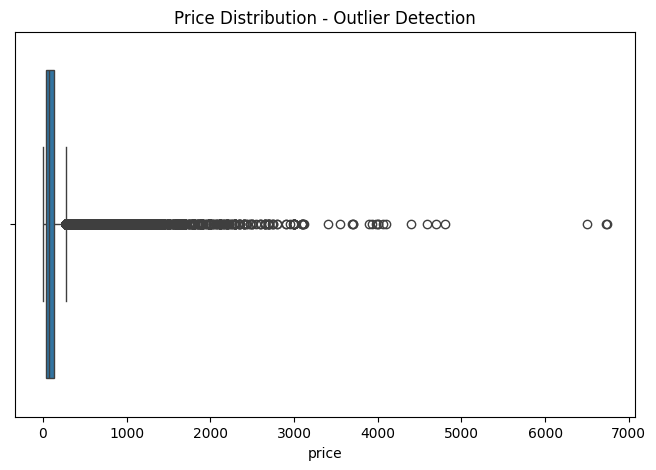

In [78]:
plt.figure(figsize=(8,5))
sns.boxplot(x=order_items['price'])
plt.title("Price Distribution - Outlier Detection")
plt.show()

In [79]:
Q1=order_items['price'].quantile(0.25)
Q3=order_items['price'].quantile(0.75)
IQR= Q3-Q1

upper=Q3+1.5*IQR
lower=Q1-1.5*IQR
outliers=order_items[(order_items['price'] < lower)|(order_items['price'] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 8427


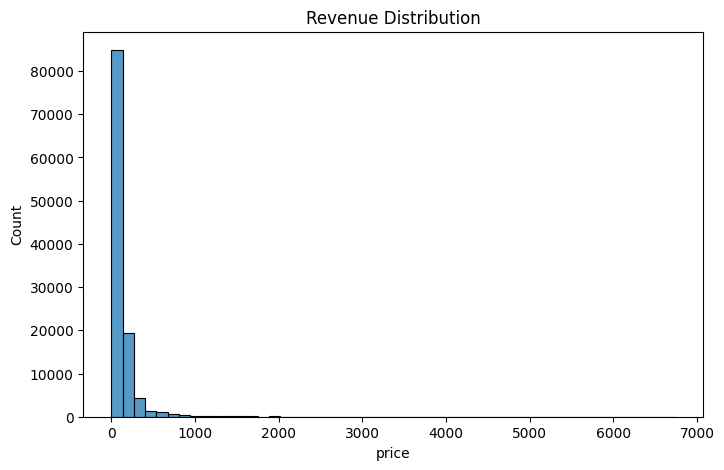

In [80]:
plt.figure(figsize=(8,5))
sns.histplot(order_items['price'],bins=50)
plt.title("Revenue Distribution")
plt.show()

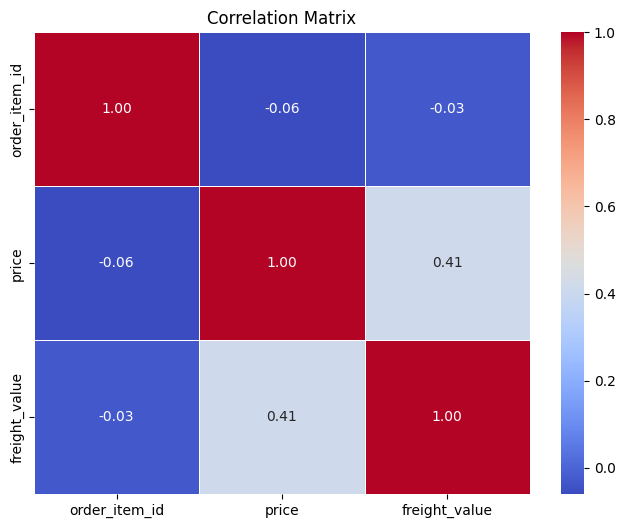

In [81]:
numeric_cols=order_items.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(),annot=True, cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [82]:
print("=== EXECUTIVE SUMMARY ===")
print("Total Orders:", orders['order_id'].nunique())
print("Total Revenue:", round(order_items['price'].sum(),2))
print("Average Delivery Time:", round(orders['delivery_time_days'].mean(),2))
print("Late Delivery %:", round(orders['is_late'].mean()*100,2))

=== EXECUTIVE SUMMARY ===
Total Orders: 99441
Total Revenue: 13591643.7
Average Delivery Time: 12.09
Late Delivery %: 7.87


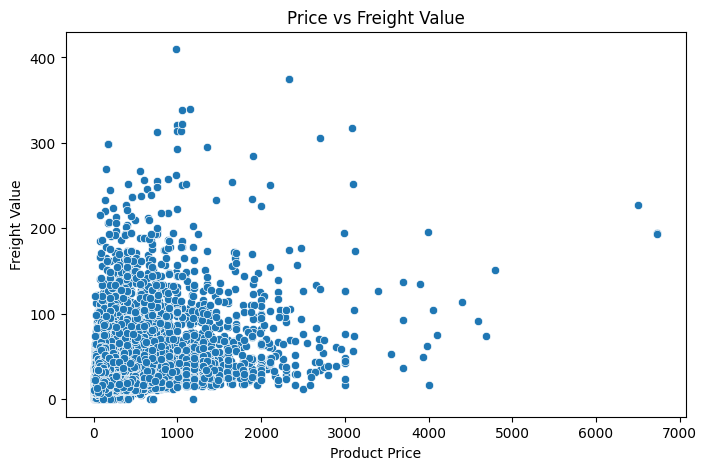

In [83]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=order_items, x='price', y='freight_value')
plt.title("Price vs Freight Value")
plt.xlabel("Product Price")
plt.ylabel("Freight Value")
plt.show()

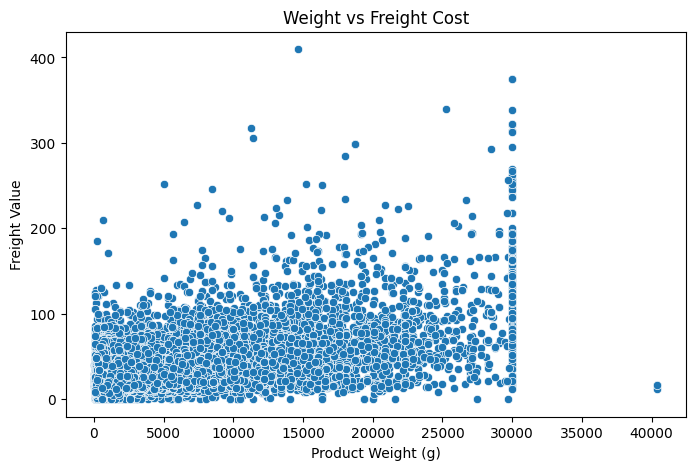

In [84]:
product_merge = pd.merge(order_items, products, on='product_id')
plt.figure(figsize=(8,5))
sns.scatterplot(data=product_merge, x='product_weight_g',y='freight_value')

plt.title("Weight vs Freight Cost")
plt.xlabel("Product Weight (g)")
plt.ylabel("Freight Value")
plt.show()

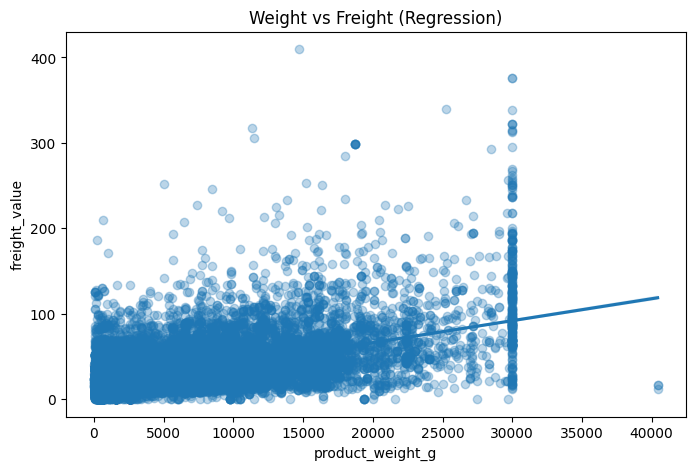

In [85]:
#add regression line

plt.figure(figsize=(8,5))
sns.regplot(data=product_merge, x='product_weight_g', y='freight_value', scatter_kws={'alpha':0.3})

plt.title("Weight vs Freight (Regression)")
plt.show()

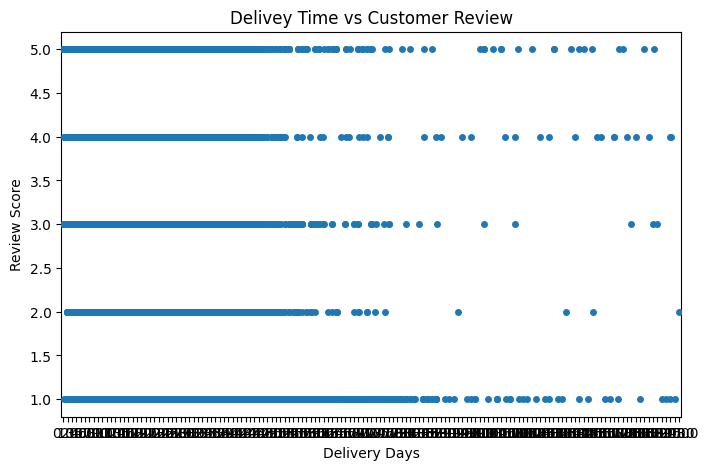

In [86]:
orders['delivery_days']=(
    orders['order_delivered_customer_date']-orders['order_purchase_timestamp']
).dt.days
delivery_review=pd.merge(orders,order_review, on='order_id')

plt.figure(figsize=(8,5))
sns.stripplot(data=delivery_review, x='delivery_days', y='review_score')
plt.title("Delivey Time vs Customer Review")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.show()

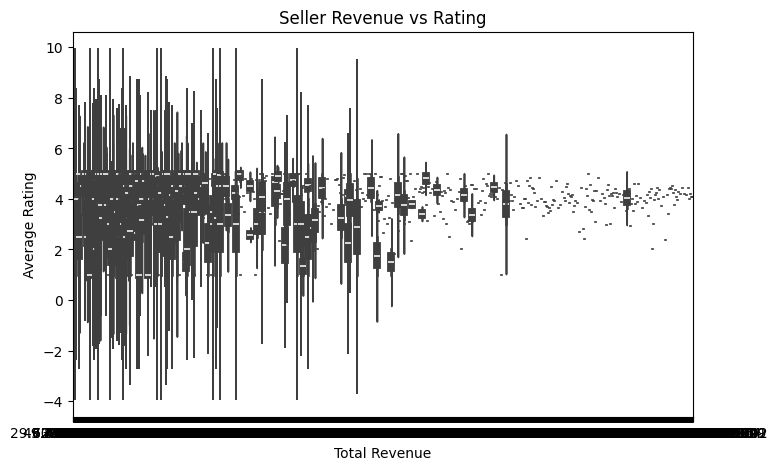

In [87]:
seller_data=pd.merge(order_items, order_review,  on ='order_id')
seller_summary= seller_data.groupby('seller_id').agg({
    'price':'sum',
    'review_score':'mean'
}).reset_index()

plt.figure(figsize=(8,5))
sns.violinplot(data=seller_summary, x='price',y='review_score')
plt.title("Seller Revenue vs Rating")
plt.xlabel("Total Revenue")
plt.ylabel("Average Rating")
plt.show()

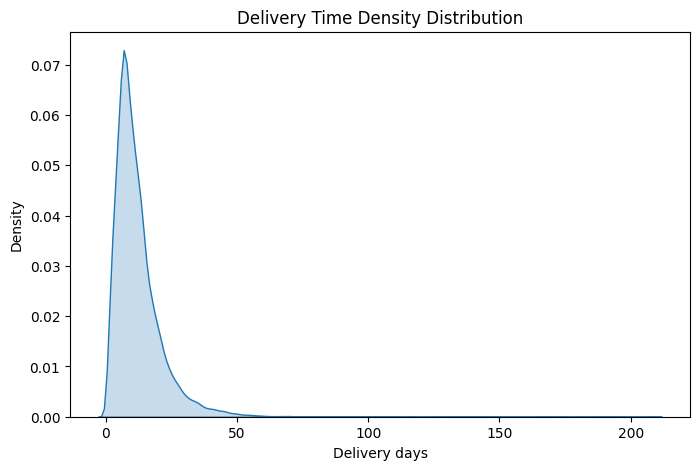

In [88]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=orders, x='delivery_days', fill=True)
plt.title("Delivery Time Density Distribution")
plt.xlabel("Delivery days")
plt.show()

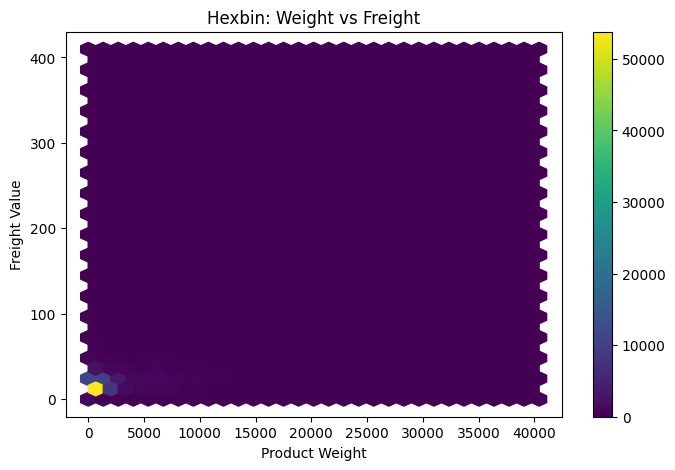

In [89]:
plt.figure(figsize=(8,5))
plt.hexbin(product_merge['product_weight_g'],product_merge['freight_value'],gridsize=30)

plt.xlabel("Product Weight")
plt.ylabel("Freight Value")
plt.title("Hexbin: Weight vs Freight")
plt.colorbar()
plt.show()

In [90]:
plt.savefig("sales_analysis.png")

<Figure size 640x480 with 0 Axes>